In [1]:
from queue import PriorityQueue
import networkx as nx
import matplotlib.pyplot as plt 

In [2]:
roteadores = dict() #Dicionário que irá armazenar os roteadores


with open("dadaset_redes.txt", "r") as arquivo: # Abre o arquivo que contém os dados da rede

    # Lê o arquivo linha por linha até o fim
    while True: 
        linha = arquivo.readline()

        if linha: # Se tiver conteúdo na linha lida
            divisao = linha.split(":") # Divide pelo ":" para separar o nó atual e sua lista de conexões no arquivo
            node = divisao[0].strip()   # Obtém o nome do roteador e remove espaços em branco

            
            roteadores[node] = eval(divisao[1].strip()) # Armazena no dicionário a lista das conexões do roteador atual 
            
        else:
            break

In [3]:
def BuscaUniforme(grafo,inicio,alvo):
    fila = PriorityQueue()  
    visitados = set()   

    fila.put((0,inicio,[inicio])) # Insere o nó inicial na fila

    while not fila.empty(): # Continua enquanto houver elementos na fila

        custoAtual, roteadorAtual, caminho = fila.get()

        # Ignora caso o nó já tenha sido visitado
        if roteadorAtual in visitados:
            continue
        
        visitados.add(roteadorAtual) # Marca o nó como visitado

        # Caso encontre o alvo retorna seu custo e o caminho realizado
        if roteadorAtual == alvo:
            return custoAtual, caminho
        
        for vizinho, custoVizinho in grafo[roteadorAtual]: # Percorre os vizinhos do nó atual
            
            if vizinho not in visitados: # Se o vizinho ainda não foi visitado
                novoCusto = custoAtual + custoVizinho # Calcula o novo custo acumulado
                novoCaminho = caminho + [vizinho] # Atualiza o caminho
                
                fila.put((novoCusto,vizinho,novoCaminho)) # Adiciona na fila com o custo acumulado e o caminho atualizado

    return "Alvo não encontrado"

In [4]:
def AlgoritmoDjikstra(grafo, inicio):
    fila = PriorityQueue()  
    menoresDistancias = dict()  # Armazena menor distância encontrada para cada nó do grafo
    ancestrais = dict() # Armazena o nó anterior de cada roteador no menor caminho encontrado semelhante a uma corrente 

    # Inicializa todas as distâncias como infinito e sem ancestral definido
    for roteador in grafo: 
        menoresDistancias[roteador] = float("inf")
        ancestrais[roteador] = None

    menoresDistancias[inicio] = 0

    fila.put((0,inicio)) # Insere o nó inicial

    while not fila.empty():
        custoAtual, roteadorAtual = fila.get()

        # Ignora caminho caso tenha custo maior que o já registrado no dicionário
        if custoAtual > menoresDistancias[roteadorAtual]:
            continue
        
        for vizinho, custoVizinho in grafo[roteadorAtual]:
            novoCusto = custoAtual + custoVizinho

            if novoCusto < menoresDistancias[vizinho]: # Se encontrou um de menor custo que o registrado

                menoresDistancias[vizinho] = novoCusto # Atualiza o menor custo encontrado para aquele vizinho
                ancestrais[vizinho] = roteadorAtual # Define o ancestral daquele caminho de menor custo

                fila.put((novoCusto,vizinho)) # Insere o vizinho na fila com o novo custo

    return menoresDistancias, ancestrais # Retorna as menores distâncias e os ancestrais para cada nó do grafo

In [5]:
def ArvoreDijkstra(ancestrais):
    arestasArvore = []  # Armazena as arestas da árvore de Dijkstra

    for roteador, ancestral in ancestrais.items(): # Para cada item no dicionário ancestrais recebe o roteador e seu respectivo ancestral
        if ancestral: # Se aquele roteador tem um ancestral
            arestasArvore.append((roteador,ancestral)) # Adiciona a tupla na lista de arestas

    return arestasArvore # Retorna as arestas

In [6]:
# Problema 1 
print("\n----- Problema 1 -----")

origem = "CORE001"
alvo = "IOT045"

custo, caminho = BuscaUniforme(roteadores,origem,alvo)

# 1.  Qual é o caminho de menor latência entre CORE001 e IOT045? 
print("\n1.  Qual é o caminho de menor latência entre CORE001 e IOT045?\nO caminho de menor latência percorre o seguinte trajeto: ", " -> ".join(str(n) for n in caminho))

# 2.  Qual é a latência total da rota encontrada? 
print("\n2.  Qual é a latência total da rota encontrada?\nA latência total encontrada foi", custo)

# 3.  Quantos roteadores foram percorridos? 
print(f"\n3.  Quantos roteadores foram percorridos?\nForam percorridos {len(caminho)} roteadores no menor caminho")


----- Problema 1 -----

1.  Qual é o caminho de menor latência entre CORE001 e IOT045?
O caminho de menor latência percorre o seguinte trajeto:  CORE001 -> CORE002 -> IOT048 -> IOT049 -> IOT036 -> IOT027 -> IOT030 -> IOT045

2.  Qual é a latência total da rota encontrada?
A latência total encontrada foi 28

3.  Quantos roteadores foram percorridos?
Foram percorridos 8 roteadores no menor caminho


In [33]:
# Problema 2
print("\n----- Problema 2 -----")

distancias, ancestrais = AlgoritmoDjikstra(roteadores,origem)

# 1.  Qual é a menor latência entre CORE001 e cada um dos 200 roteadores da rede?
print("\n1. Qual é a menor latência entre CORE001 e cada um dos 200 roteadores da rede?\n " + " \n ".join(f"{roteador}: {distancia}ms" for roteador, distancia in distancias.items()))

# 2.  Qual roteador apresenta a maior latência em relação ao servidor central? 
print(f"\n2.  Qual roteador apresenta a maior latência em relação ao servidor central?\nO roteador de maior latência em relação ao servidor central foi {max(distancias, key=distancias.get)}")

# 3.  Qual é a latência média da rede? 
print(f"\n3.  Qual é a latência média da rede?\nA latência média encontrada foi {sum(distancias.values())/len(distancias)}")

# 4.  Plote o grafo original e destaque, em outra cor, as arestas pertencentes à árvore produzida pelo Dijkstra. 
print("\n4.  Plote o grafo original e destaque, em outra cor, as arestas pertencentes à árvore produzida pelo Dijkstra.")


----- Problema 2 -----

1. Qual é a menor latência entre CORE001 e cada um dos 200 roteadores da rede?
 CORE001: 0ms 
 CORE002: 2ms 
 CORE003: 2ms 
 CORE004: 7ms 
 CORE005: 9ms 
 CORE006: 5ms 
 CORE007: 6ms 
 CORE008: 4ms 
 CORE009: 13ms 
 CORE010: 13ms 
 CORE011: 4ms 
 CORE012: 10ms 
 CORE013: 9ms 
 CORE014: 8ms 
 CORE015: 6ms 
 CORE016: 10ms 
 CORE017: 13ms 
 CORE018: 11ms 
 CORE019: 6ms 
 CORE020: 5ms 
 FIN001: 14ms 
 FIN002: 18ms 
 FIN003: 24ms 
 FIN004: 17ms 
 FIN005: 21ms 
 FIN006: 25ms 
 FIN007: 26ms 
 FIN008: 21ms 
 FIN009: 22ms 
 FIN010: 25ms 
 FIN011: 18ms 
 FIN012: 24ms 
 FIN013: 26ms 
 FIN014: 23ms 
 FIN015: 21ms 
 FIN016: 27ms 
 FIN017: 27ms 
 FIN018: 25ms 
 FIN019: 20ms 
 FIN020: 22ms 
 FIN021: 28ms 
 FIN022: 25ms 
 FIN023: 26ms 
 FIN024: 27ms 
 FIN025: 28ms 
 FIN026: 33ms 
 FIN027: 24ms 
 FIN028: 26ms 
 FIN029: 21ms 
 FIN030: 23ms 
 RH001: 32ms 
 RH002: 34ms 
 RH003: 44ms 
 RH004: 46ms 
 RH005: 41ms 
 RH006: 37ms 
 RH007: 35ms 
 RH008: 34ms 
 RH009: 37ms 
 RH010: 41ms 


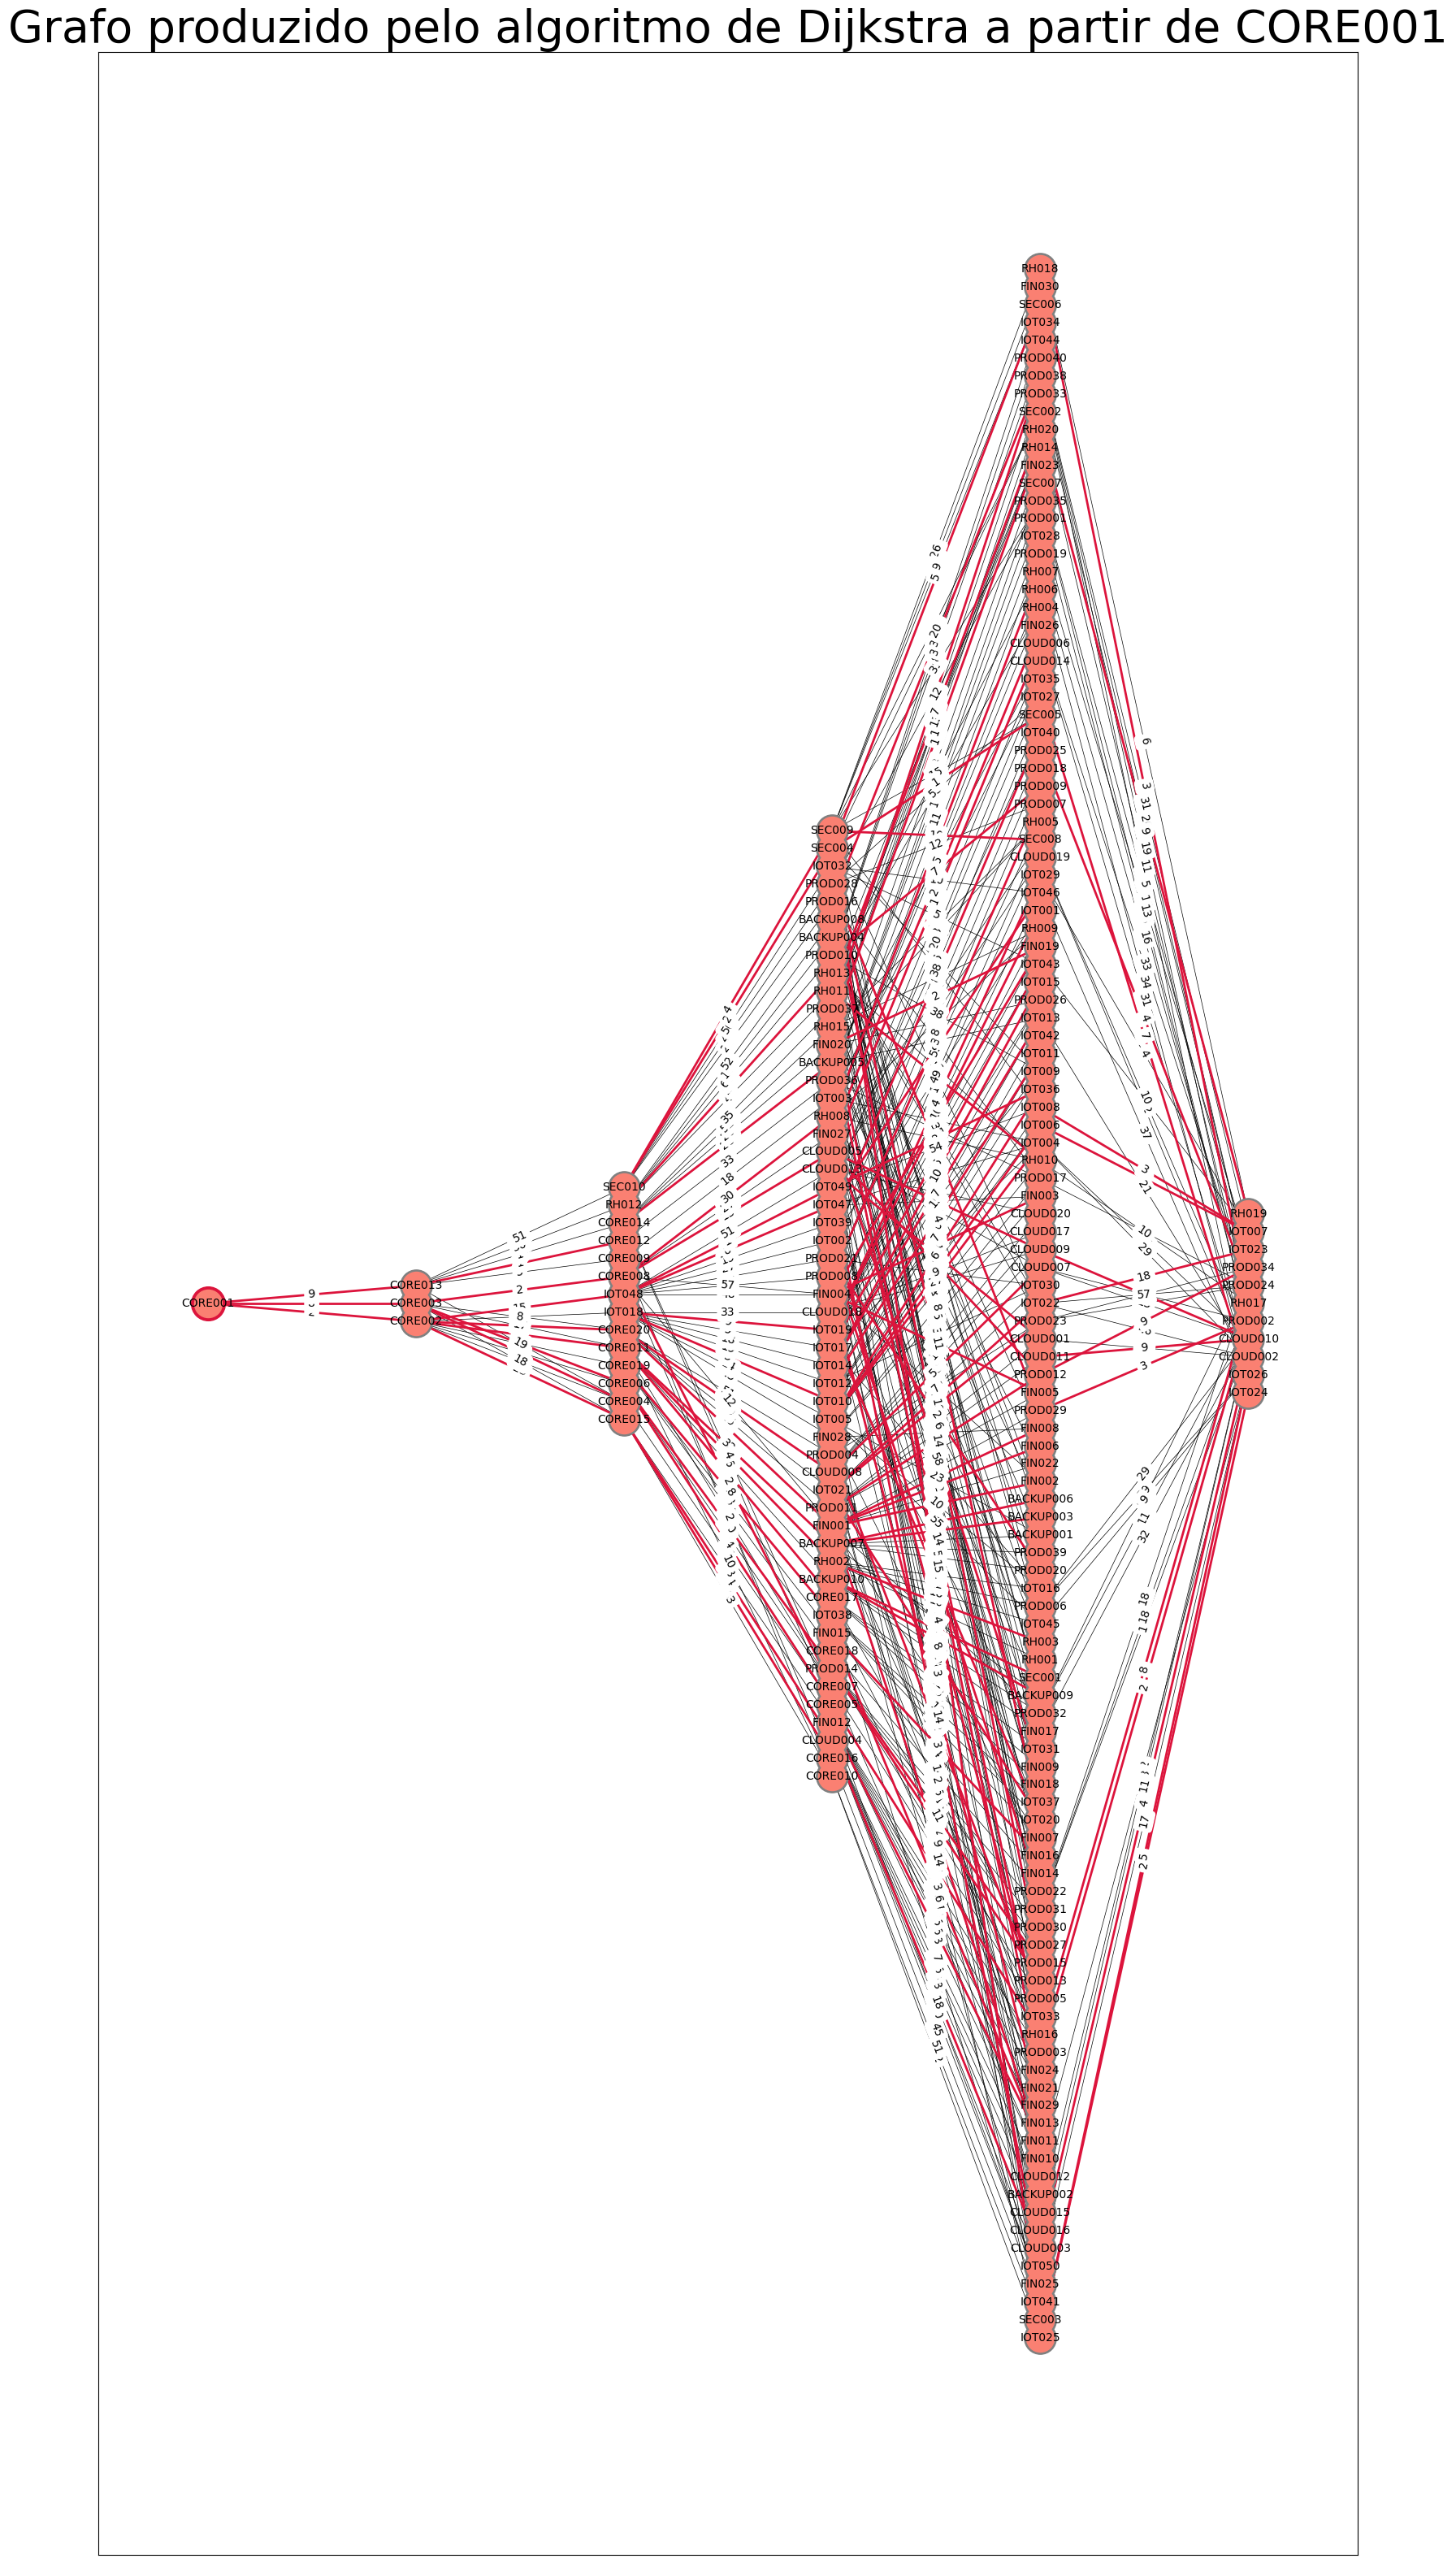

In [31]:
arestas = ArvoreDijkstra(ancestrais)

nos_arvore = set()

for origem_aresta, destino_aresta in arestas:
    nos_arvore.add(origem_aresta)
    nos_arvore.add(destino_aresta)

grafo = nx.Graph()

for roteador, vizinhos in roteadores.items():
    for vizinho, custo in vizinhos:
        grafo.add_edge(roteador,vizinho,weight=custo)

plt.figure(figsize=(20, 40))
pos = nx.bfs_layout(grafo,origem)
for no in pos:
    pos[no][1] *= 6

nx.draw_networkx_edges(grafo,pos,width=0.5)
nx.draw_networkx_edges(grafo,pos,edge_color="crimson",edgelist=arestas,width=2)

nx.draw_networkx_nodes(grafo,pos,node_color="gray",node_size=800)
nx.draw_networkx_nodes(grafo,pos,node_color="crimson",nodelist=[origem],node_size=900)
nx.draw_networkx_nodes(grafo,pos,node_color="salmon",nodelist=list(nos_arvore),node_size=600)

nx.draw_networkx_labels(grafo,pos,font_size=10)
peso = nx.get_edge_attributes(grafo,"weight")
nx.draw_networkx_edge_labels(grafo,pos,edge_labels=peso,font_size=10)

plt.title(f"Grafo produzido pelo algoritmo de Dijkstra a partir de {origem}",fontsize=40)
plt.show()